## 1. Import the librarys

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_rows",30)
pd.set_option('display.max_columns', None)

## 2. Load the data

In [2]:
df = pd.read_csv("../data/data.csv")
df.shape

(2000, 21)

In [3]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [5]:
df["price_range"].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

|values|Range|
|-----------:|----------------|
|0|low cost|
|1|medium cost|
|2|high cost|
|3|very high cost|

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


## 3. EDA

In [7]:
missing_value = df.isnull().sum().sum()
print("Missing value : ",missing_value)

Missing value :  0


In [8]:
df.duplicated().sum()

np.int64(0)

### 3.1 Target Variable analysis

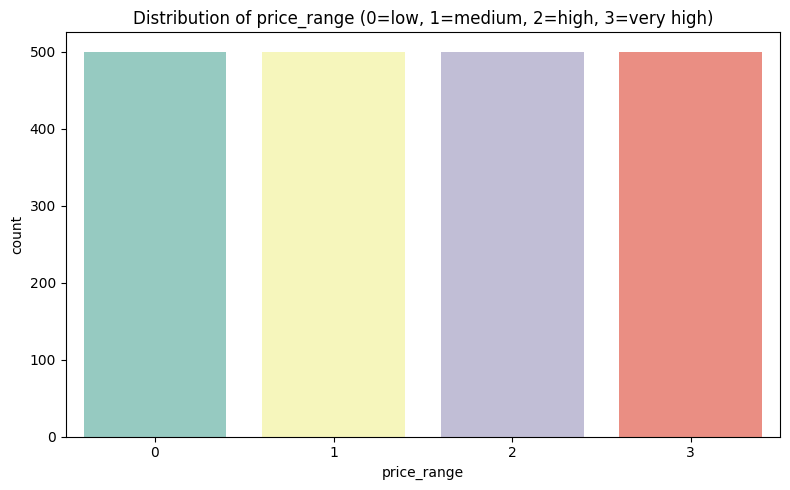

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="price_range", palette="Set3")
plt.title("Distribution of price_range (0=low, 1=medium, 2=high, 3=very high)")
plt.tight_layout()
plt.savefig("../images/eda plots/Distribution_target_variable.png")
plt.show()

### 3.2 Univariant analysis

In [10]:
numerical_features = [
    'battery_power',
    'clock_speed',
    'fc',
    'int_memory',
    'm_dep',
    'mobile_wt',
    'n_cores',
    'pc',
    'px_height',
    'px_width',
    'ram',
    'sc_h',
    'sc_w',
    'talk_time'
]

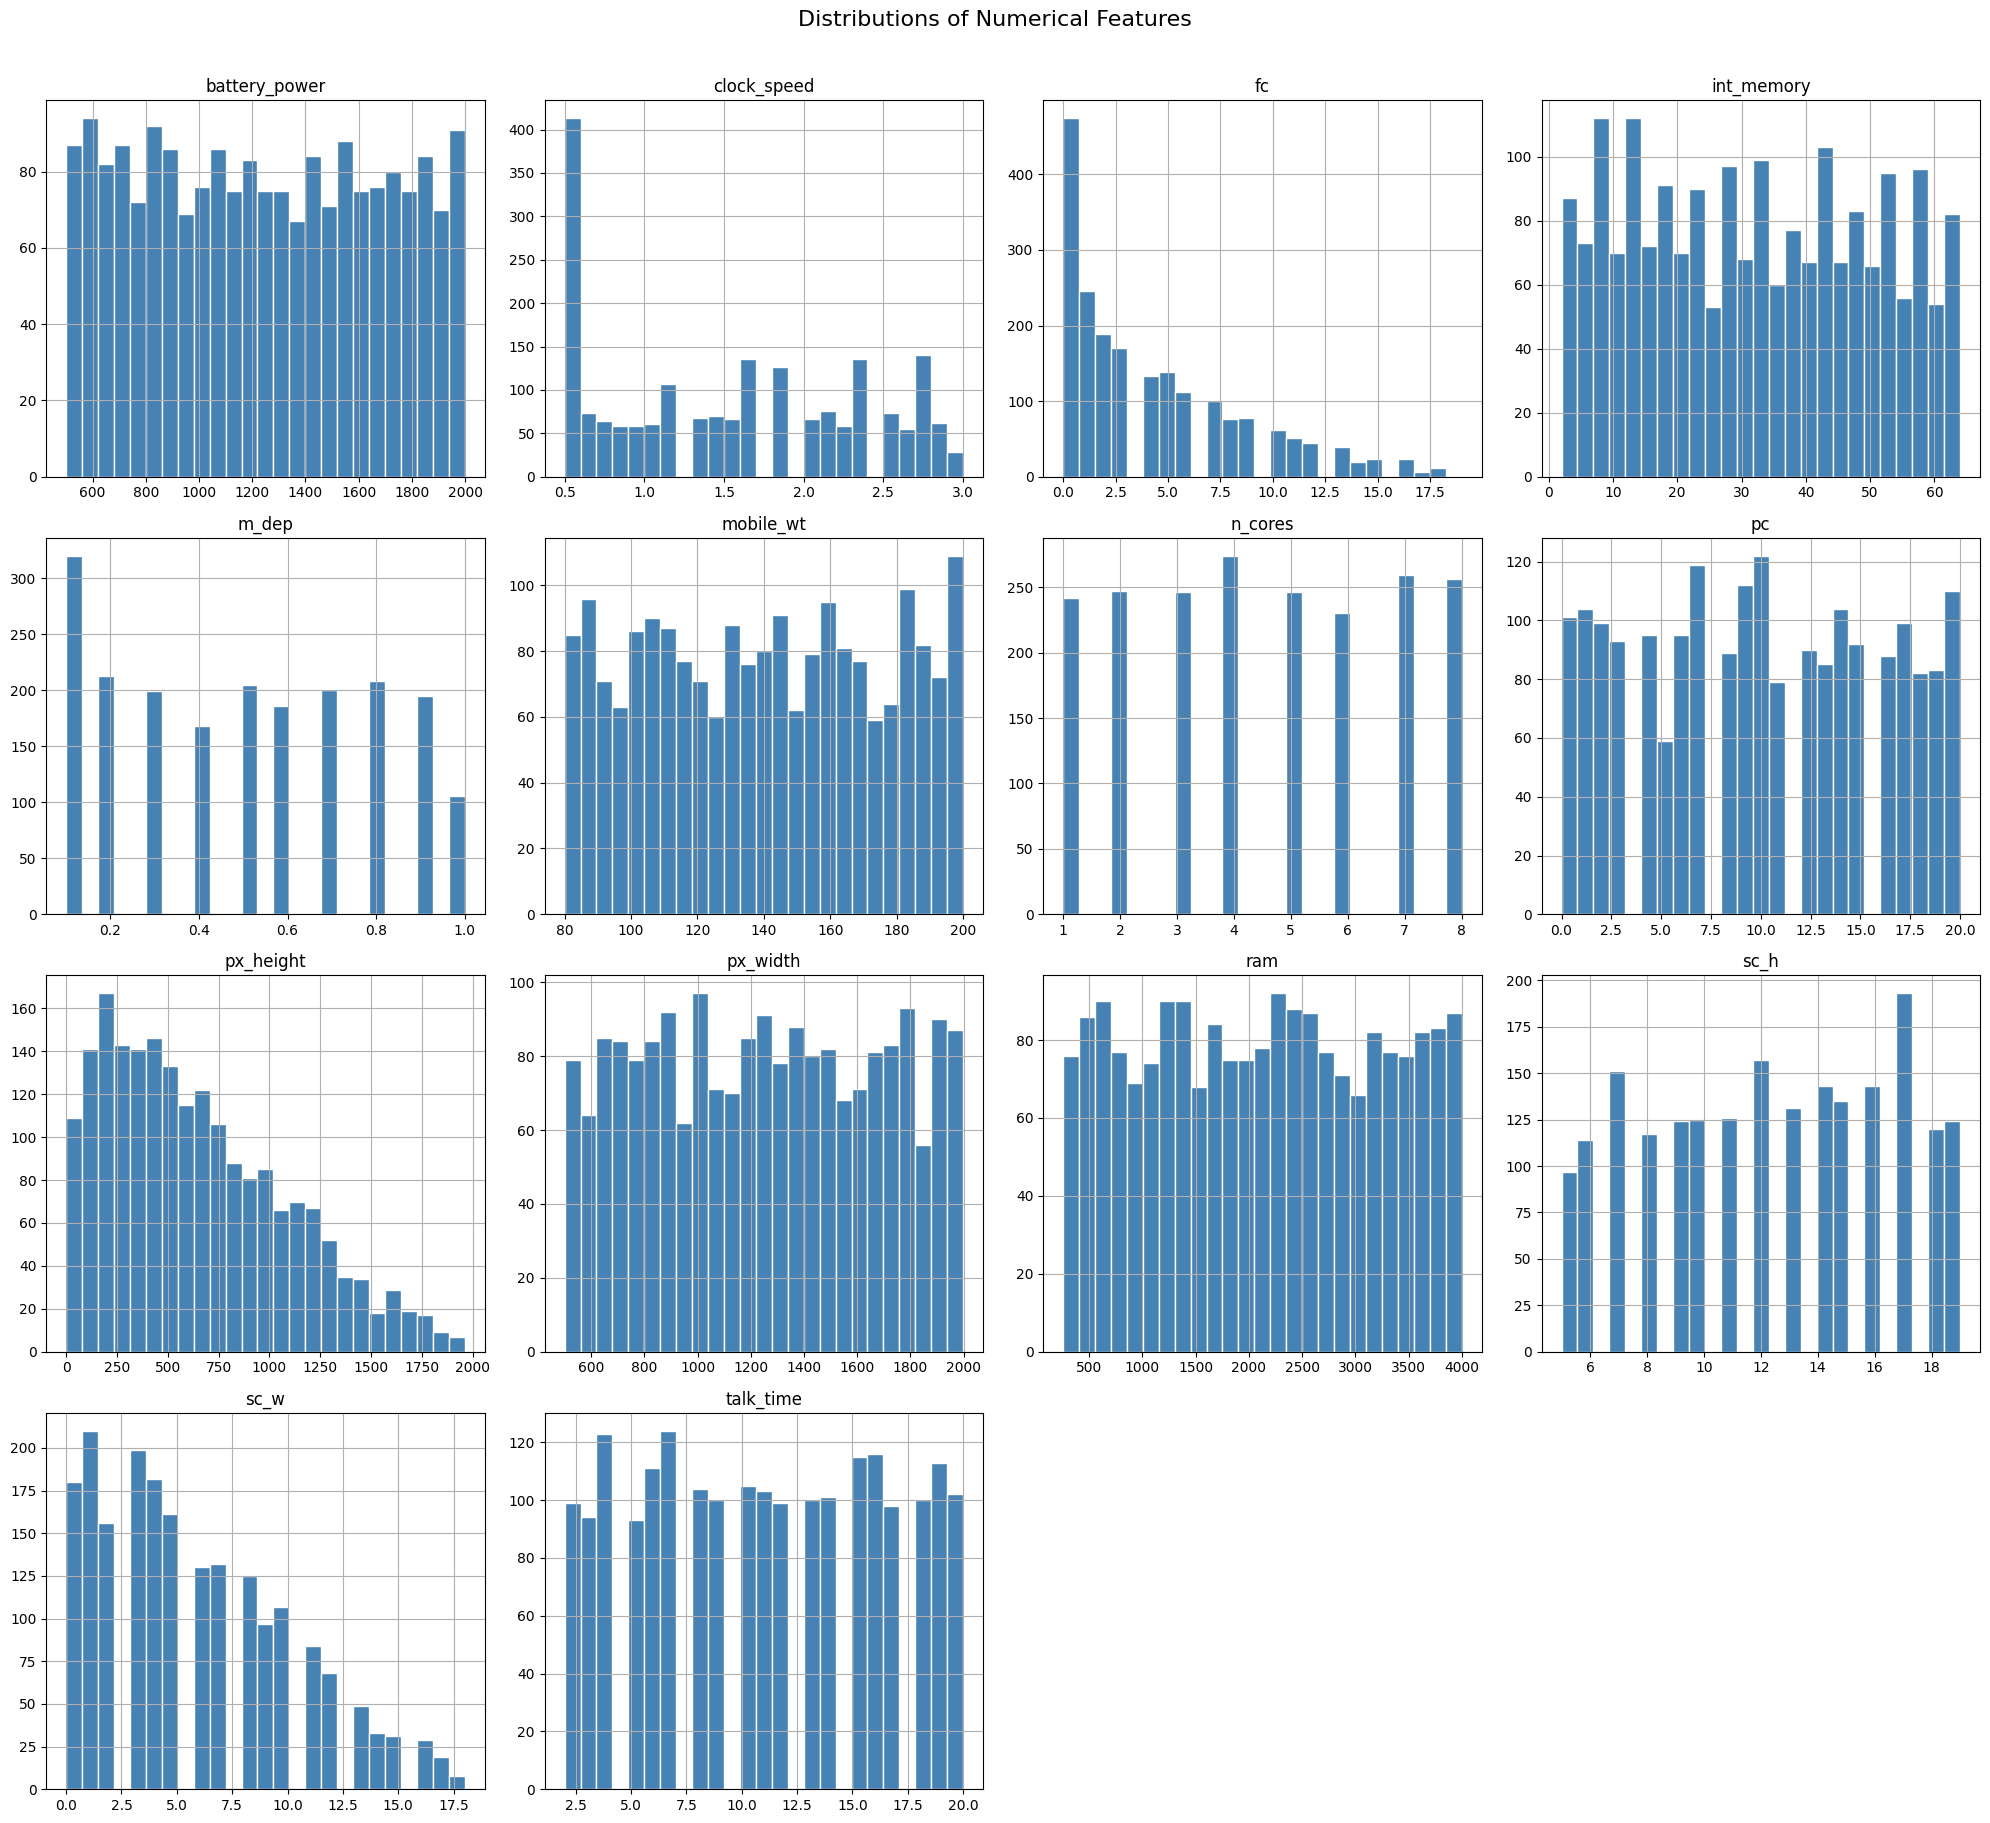

In [11]:
df[numerical_features].hist(figsize=(20,18), bins=25, color="steelblue", edgecolor="white")
plt.suptitle('Distributions of Numerical Features', y=1.01, fontsize=16)
plt.tight_layout()
plt.savefig("../images/eda plots/Univariant_Numerical.png")
plt.show()

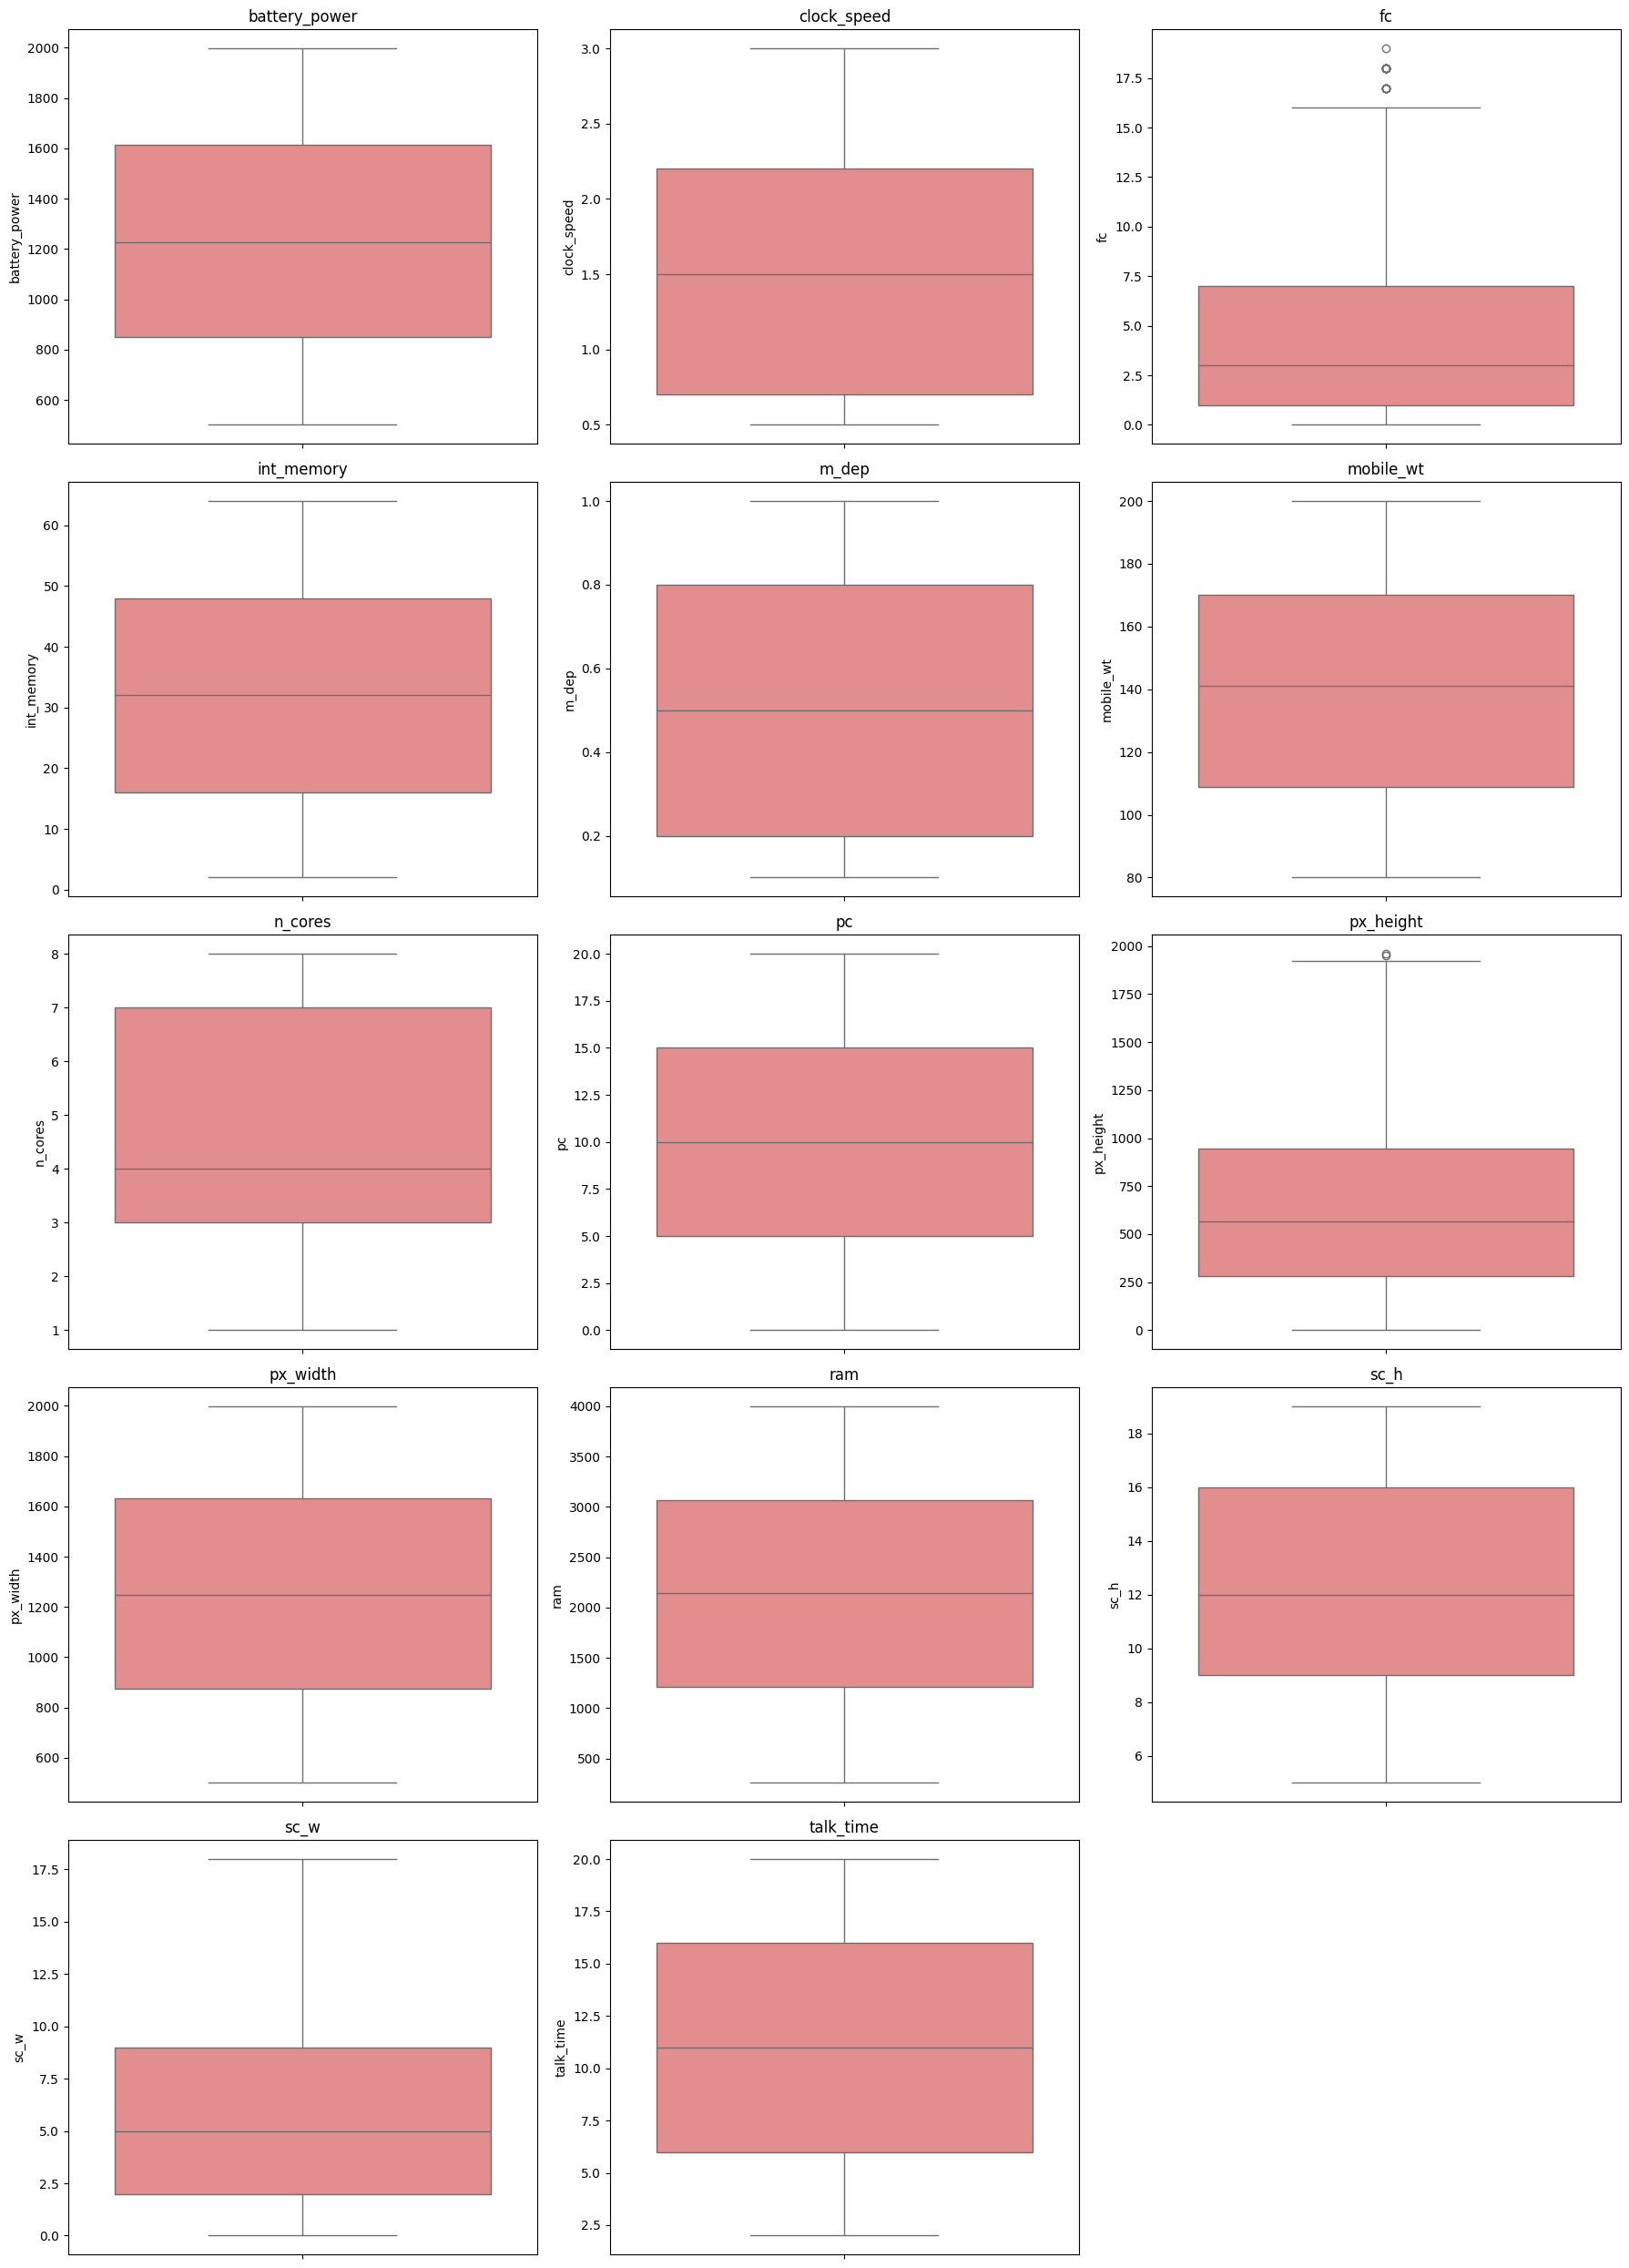

In [12]:
import math

n_cols = 3
n_rows = math.ceil(len(numerical_features) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=df, y=col, color="lightcoral")
    plt.title(col)
    plt.xticks(rotation=45)

plt.savefig("../images/eda plots/Boxplot_numerical_feature.png")
plt.tight_layout()
plt.show()

In [13]:
for col in numerical_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]
    print(col,":",  len(outliers))

battery_power : 0
clock_speed : 0
fc : 18
int_memory : 0
m_dep : 0
mobile_wt : 0
n_cores : 0
pc : 0
px_height : 2
px_width : 0
ram : 0
sc_h : 0
sc_w : 0
talk_time : 0


In [14]:
categorical_features = [
    'blue',
    'dual_sim',
    'four_g',
    'three_g',
    'touch_screen',
    'wifi'
]

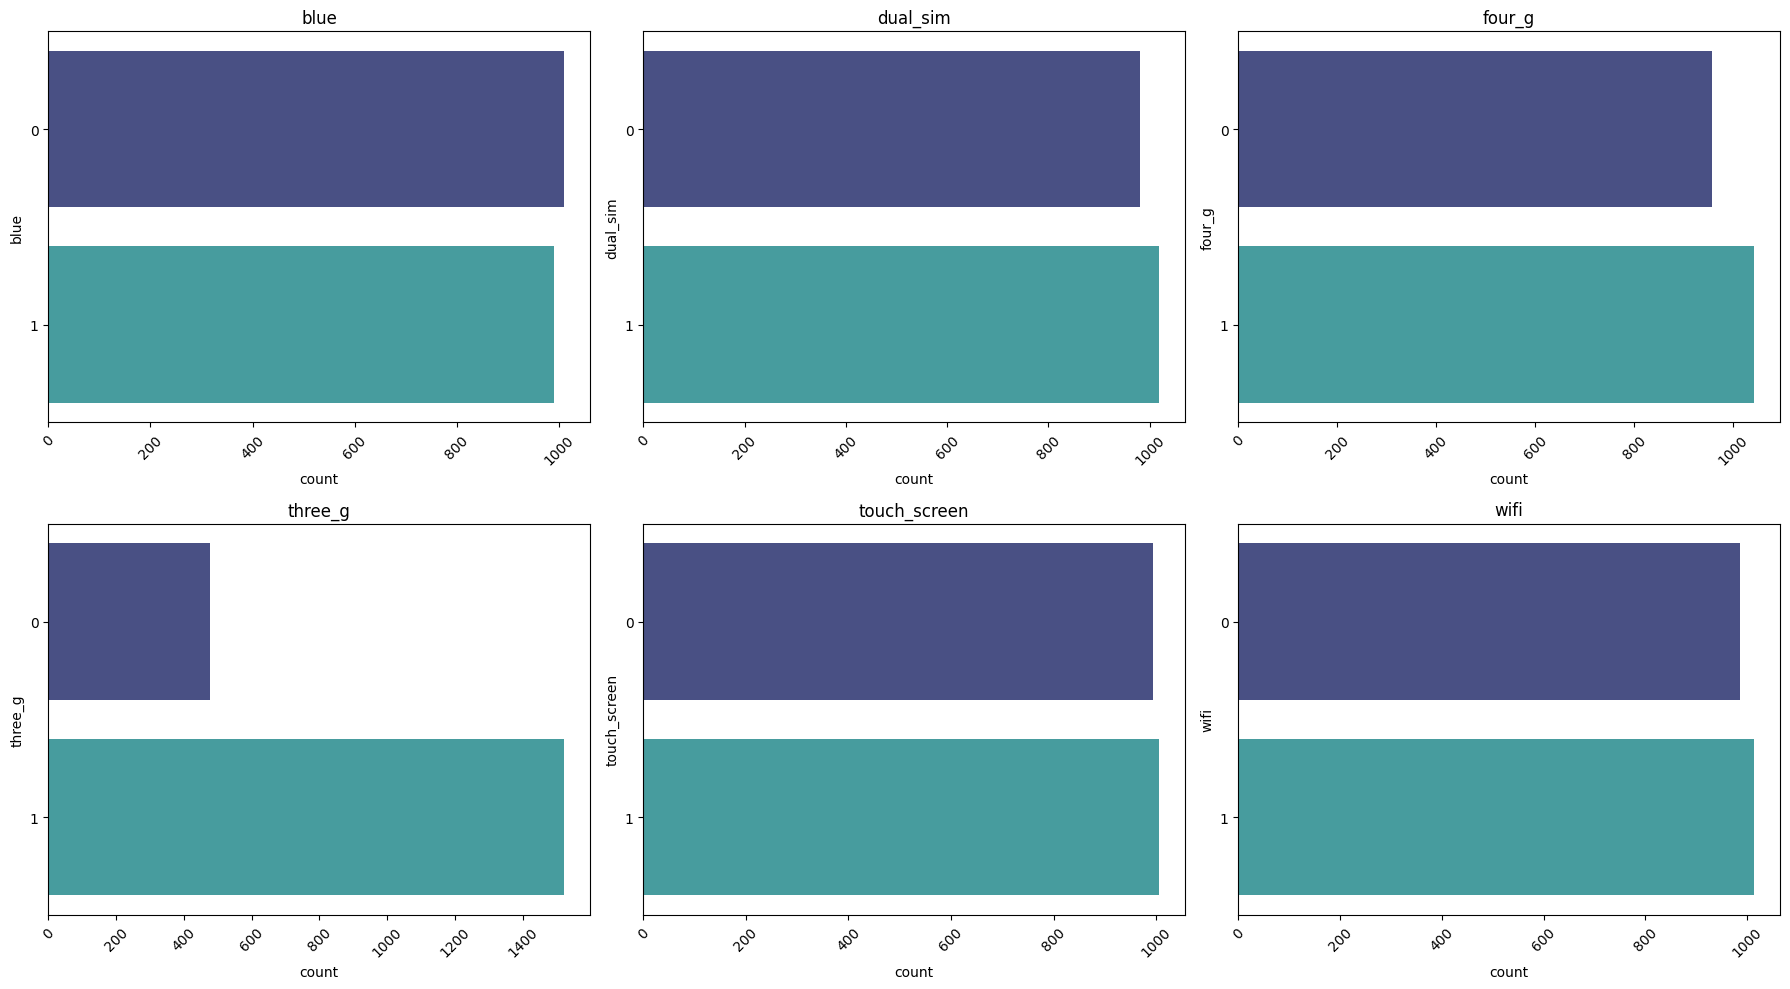

In [15]:
import math

n_cols = 3
n_rows = math.ceil(len(categorical_features) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=df, y=col,hue=col, palette="mako", legend=False)
    plt.title(col)
    plt.xticks(rotation=45)

plt.savefig("../images/eda plots/Univariant_Categorical.png")
plt.tight_layout()
plt.show()

### 3.3 Correlation of features

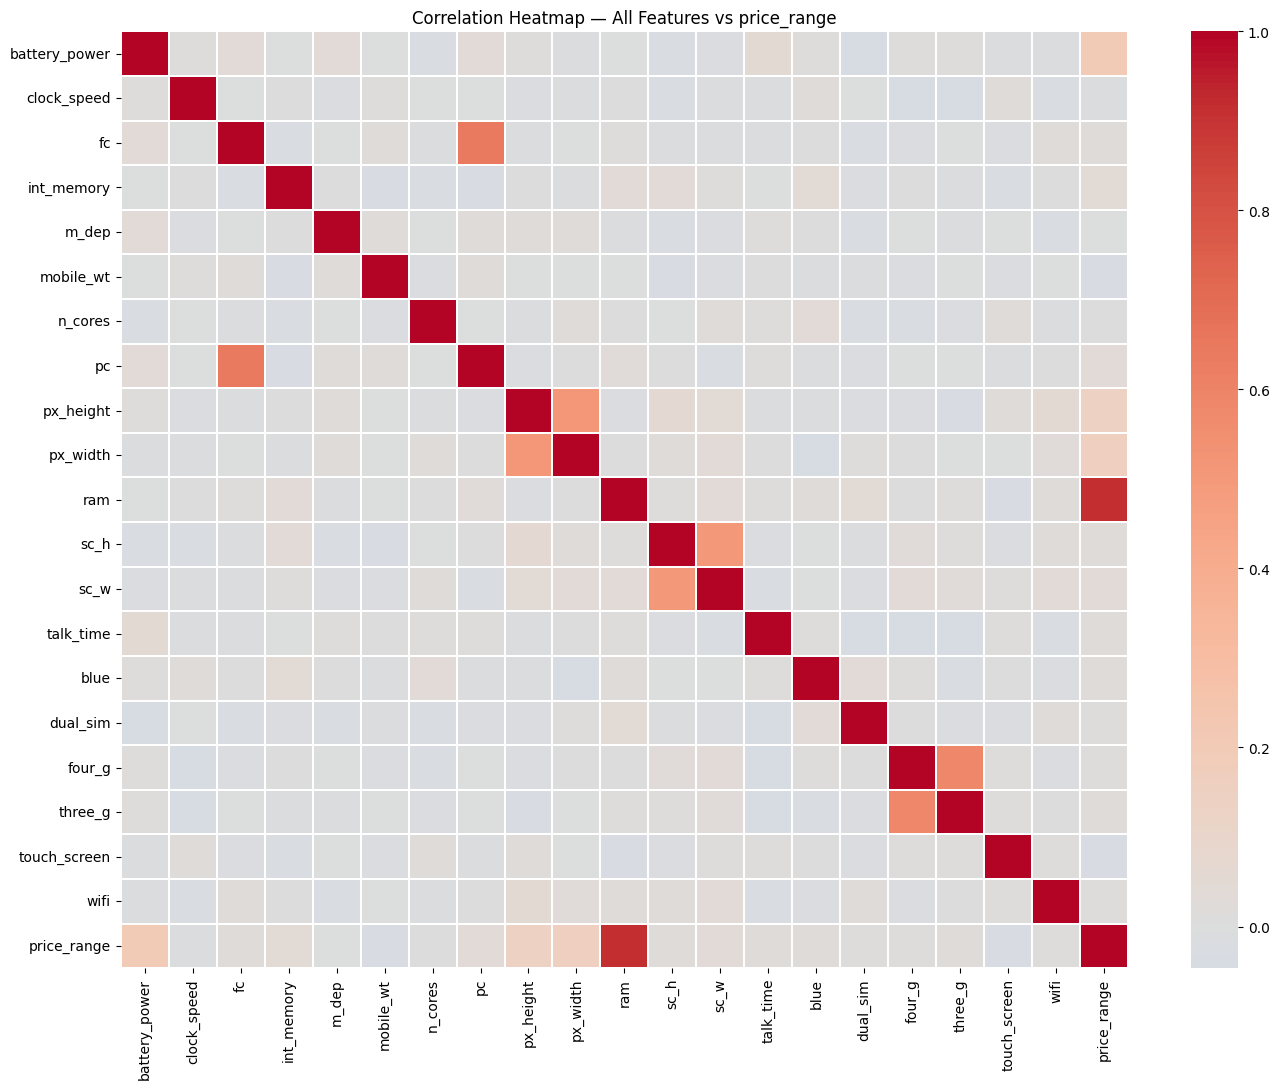

In [16]:
feature_corr = df[numerical_features + categorical_features + ["price_range"]].corr()
plt.figure(figsize=(14, 11))
sns.heatmap(feature_corr, linewidths=0.3, cmap="coolwarm", center=0)
plt.title('Correlation Heatmap — All Features vs price_range')
plt.tight_layout()
plt.show()

In [17]:
target_corr = feature_corr["price_range"].drop("price_range").sort_values(ascending=False)
print("Top Correaltion with price_range")
print(target_corr)

Top Correaltion with price_range
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


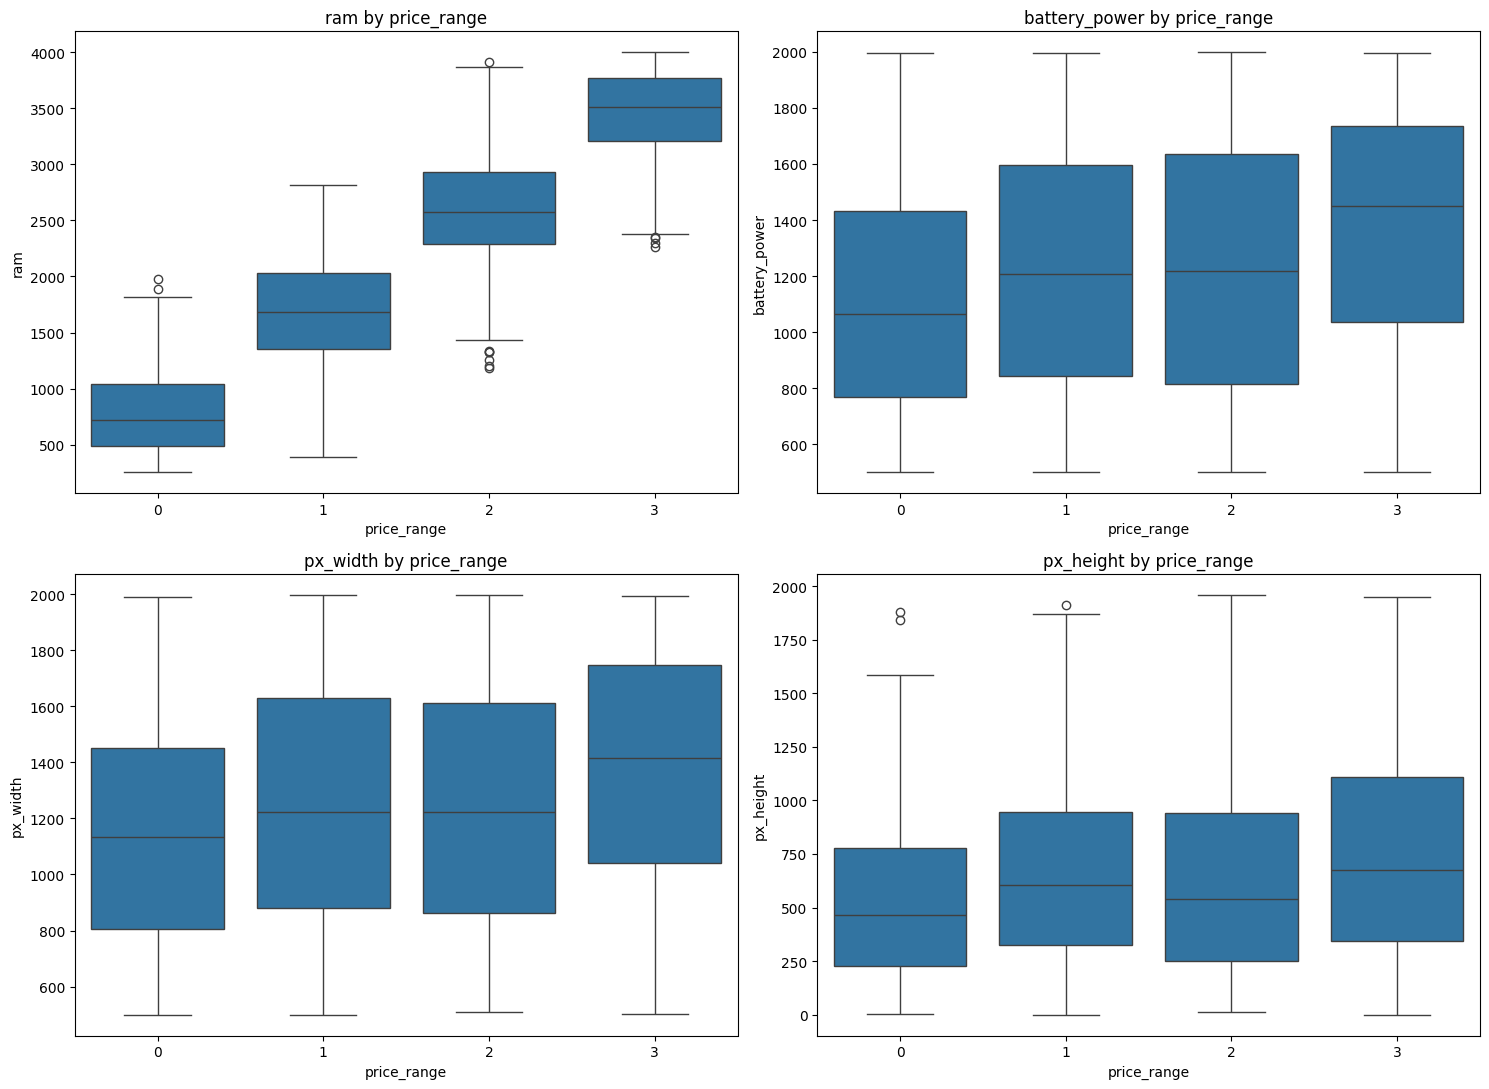

In [18]:
bar_feature = ["ram", "battery_power", "px_width", "px_height"]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, col in zip(axes.flat, bar_feature):
    sns.boxplot(data=df, x="price_range", y=col, ax=ax)
    ax.set_title(f"{col} by price_range")

plt.tight_layout()
plt.show()

## 4. Train Test Split

In [19]:
x = df.drop(columns={"price_range"})
y = df["price_range"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

print("Train : ",x_train.shape)
print("Test : ", x_test.shape)

Train :  (1600, 20)
Test :  (400, 20)


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

## 5. Model Selection

In [21]:
models = {
    "LogisticRegression" : LogisticRegression(max_iter=1000, random_state=42),
    "KNN" : KNeighborsClassifier(n_neighbors=9),
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'XGBClassifier' : XGBClassifier(random_state=42, eval_metric='mlogloss')
}

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
fitted_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="accuracy")

    results.append({
        "Model" : name,
        "Test Accuracy" : accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
        'CV Accuracy (mean)': cv_score.mean(),
        'CV Accuracy (std)': cv_score.std(),
    })

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results_df

results_df.to_csv("../model/model_result.csv")

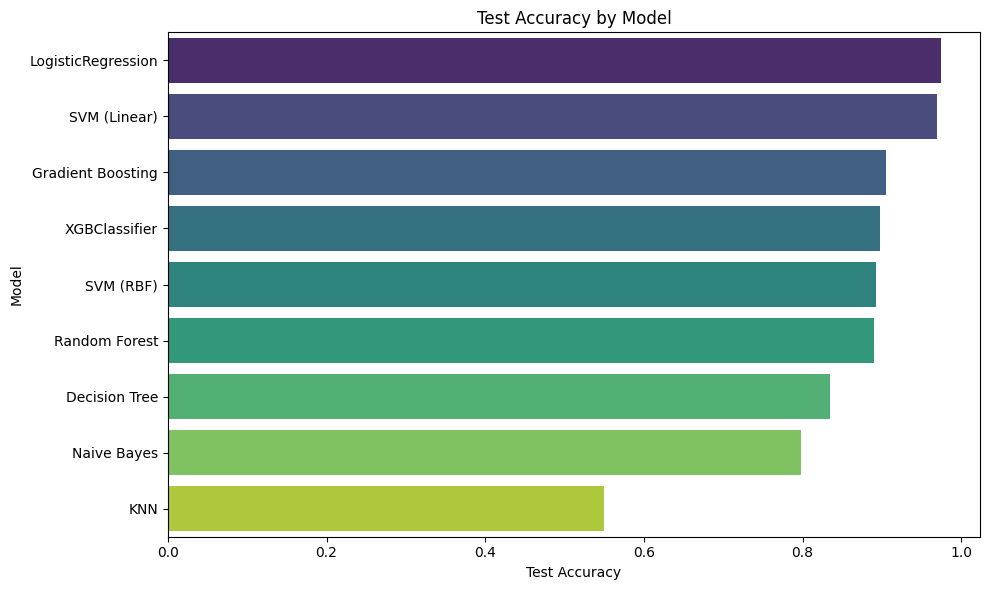

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Test Accuracy", y="Model", palette='viridis')
plt.title("Test Accuracy by Model")
plt.tight_layout()
plt.savefig("../images/model_performance_plot/Test_Accuracy_by_Model.png")
plt.show()

In [24]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
best_pred = predictions[best_model_name]

cm = confusion_matrix(y_test, best_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1", "Actual 2", "Actual 3"],
    columns=["Predicted 0", "Predicted 1", "Predicted 2", "Predicted 3"]
)
display(cm_df)

print(f"Best model by test accuracy: {best_model_name}")
print(f"Test Accuracy: {results_df.iloc[0]['Test Accuracy']:.4f}")
cm_df.to_csv("../model/confusion_matrix.csv")

,Predicted 0,Predicted 1,Predicted 2,Predicted 3
Actual 0,101,4,0,0
Actual 1,0,91,0,0
Actual 2,0,2,87,3
Actual 3,0,0,1,111


Best model by test accuracy: LogisticRegression
Test Accuracy: 0.9750


## 6. Hyperprameter Tunning

In [25]:
param_grids = {
    'LogisticRegression': {'C': [0.01, 0.1, 1, 10, 100]},          # was 'Logistic Regression'
    'SVM (Linear)': {'C': [0.01, 0.1, 1, 10, 100]},
    'SVM (RBF)': {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.001]},
    'KNN': {'n_neighbors': [3,5,7,9,11,15,21]},
    'Random Forest': {'n_estimators': [200, 400], 'max_depth': [None, 10, 20], 'min_samples_leaf':[1,2,4]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'max_depth': [2,3,4], 'learning_rate':[0.05,0.1]},
    'Decision Tree': {'max_depth': [4,6,8,10,None], 'min_samples_leaf':[1,2,4,8]},
    'Naive Bayes': {},
    'XGBClassifier': {'n_estimators':[100,200], 'max_depth':[3,4,5], 'learning_rate':[0.05,0.1]}  # was 'XGBoost'
}

In [26]:
grid = GridSearchCV(
    best_model,
    param_grids[best_model_name],
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

tuned_model = grid.best_estimator_

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

tuned_pred = tuned_model.predict(X_test_scaled)

print("\nTuned model test accuracy:", accuracy_score(y_test, tuned_pred))
print("\n", classification_report(y_test, tuned_pred))

Best params: {'C': 100}
Best CV accuracy: 0.96875

Tuned model test accuracy: 0.975

               precision    recall  f1-score   support

           0       1.00      0.94      0.97       105
           1       0.93      1.00      0.96        91
           2       0.99      0.97      0.98        92
           3       0.98      0.99      0.99       112

    accuracy                           0.97       400
   macro avg       0.97      0.98      0.97       400
weighted avg       0.98      0.97      0.98       400



In [27]:
import pickle
with open("../model/model.pkl", "wb") as file:
    pickle.dump(tuned_model, file)